In [3]:
import pandas as pd
from tashaphyne.stemming import ArabicLightStemmer
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [2]:
import pandas as pd
dataset = pd.read_csv("../datasets/AraPoems_Dataset.csv")

In [4]:
list_of_requierd = ["قصائد غزل","قصائد هجاء","قصائد مدح","قصائد رثاء"]

In [5]:
da = dataset[dataset['type_ar'].isin( list_of_requierd)]

In [6]:
da2 = pd.DataFrame()
da2["poem"] = da["first_hemistich"]+" "+da["second_hemistich"]
da2["type"] = da["type_ar"]

In [29]:
da2["type"].value_counts()

type
قصائد مدح     160797
قصائد هجاء     50377
قصائد رثاء     41001
قصائد غزل      34536
Name: count, dtype: int64

In [7]:
da["era"].unique()

array(['Pre_Islam', 'Abbasid', 'Umayyad', 'Mamluk', 'Seasoned', 'Fatimid',
       'Dual_eras', 'Ayyubid', 'Modern', 'Ottoman', 'Islamic',
       'Andalusian', nan], dtype=object)

In [8]:
only_andalus = da2[da["era"] == "Andalusian"]

In [9]:
non_andalus = da2[da["era"] != "Andalusian"]

In [10]:
non_andalus["type"].value_counts()

type
قصائد مدح     143428
قصائد هجاء     45541
قصائد رثاء     36422
قصائد غزل      32342
Name: count, dtype: int64

In [11]:
da2

,poem,type
36,على مثل ابن مية فانعياه تشق نواعم البشر الجيوبا,قصائد رثاء
37,وكان أبي عتيبة شمريا فلا تلقاه يدخر النصيبا,قصائد رثاء
38,ضروبا للكمي إذا اشمعلت عوان الحرب لا ورعا هيوبا,قصائد رثاء
68,ليس من مات فاستراح بميت إنما الميت ميت الأحياء,قصائد رثاء
71,ليس من مات فاستراح بميت إنما الميت ميت الاحياء,قصائد رثاء
...,...,...
2090662,وتوضع مجمر الركبان أن وجدنا في مراس الحرب خورا,قصائد مدح
2090863,ولي قلب أشد من الرواسي وذكري مثل عرف المسك نامي,قصائد غزل
2090864,وكيف يكون لي عزم وجسمي تراه قد بقي منه الأقل,قصائد غزل
2090865,وأرجع وهي قد ولت خفاف محيرة من الشكوى تكل,قصائد غزل


In [12]:
df_sampled = non_andalus.groupby('type').head(300)
# df_sampled_rest = da2.groupby("type").head(10000)[250:]

In [13]:
df_sampled = df_sampled.dropna()

In [14]:
df_sampled["type"].value_counts()

type
قصائد رثاء    300
قصائد غزل     300
قصائد مدح     300
قصائد هجاء    300
Name: count, dtype: int64

In [15]:
df_sampled11 = da2.groupby('type').head(700)
df_sampled11 = df_sampled11[300:]

In [16]:
df_sampled11["type"].value_counts()

type
قصائد هجاء    672
قصائد غزل     635
قصائد مدح     604
قصائد رثاء    589
Name: count, dtype: int64

In [17]:
fff = df_sampled['type'].astype('category').cat.codes

In [18]:
# ====================================================
# FINE-TUNING WITH VALIDATION - SIMPLE VERSION
# ====================================================

# 1. Install
# !pip install -q transformers datasets pandas sklearn

# 2. Imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 3. Your Data
texts = df_sampled["poem"]  # 100 samples

labels = fff

# 4. Split into train and validation (80/20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, 
    test_size=0.2,  # 20% for validation
    random_state=42,  # For reproducibility
    stratify=labels  # Maintain class distribution
)

print(f"Train samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")

# 5. Create datasets
train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_dataset = Dataset.from_dict({"text": val_texts, "label": val_labels})

# 6. Load tokenizer and model
model_name = "../arapoembert_len32_baseline/model"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Fix padding token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(set(labels))
)


# 7. Tokenize function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=32
    )

def predict_texts(texts, model, tokenizer, max_length=32):
    """
    Predict labels for a list of texts using a trained model.
    
    Args:
        texts (list or str): Single text or list of texts to predict
        model: Trained HuggingFace model
        tokenizer: Corresponding tokenizer
        max_length (int): Maximum sequence length (default: 32)
    
    Returns:
        dict: Dictionary containing predictions, probabilities, and labels
    """
    # Convert single string to list for uniform processing
    if isinstance(texts, str):
        texts = [texts]
    
    # Tokenize the texts
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    
    # Move inputs to the same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Get predictions
    model.eval()  # Set model to evaluation mode
    import torch
    
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = outputs.logits
        probabilities = torch.softmax(predictions, dim=-1)
        
        # Get predicted classes
        predicted_classes = torch.argmax(predictions, dim=-1)
    
    # Convert to numpy/python lists
    predicted_classes = predicted_classes.cpu().numpy().tolist()
    probabilities = probabilities.cpu().numpy()
    
    # Create results dictionary
    results = {
        'texts': texts,
        'predictions': predicted_classes,
        'probabilities': probabilities,
        'confidence': [max(probs) for probs in probabilities]
    }
    
    # If you have label names (optional)
    # label_names = ['class_0', 'class_1', ...]  # Define your label names
    # results['predicted_labels'] = [label_names[p] for p in predicted_classes]
    
    return results

# Tokenize both datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Remove text column
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

# 8. Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
    }

# 9. Training arguments with validation
training_args = TrainingArguments(
    output_dir="./results_lena",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,  # Batch size for validation
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",         # Save at each epoch
    load_best_model_at_end=True,   # Load the best model when finished
    metric_for_best_model="f1_macro",  # Which metric to use for best model
    greater_is_better=True,         # Higher F1 is better
    save_total_limit=2,             # Keep only 2 best models
)

# 10. Create trainer with validation dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Add validation dataset
    compute_metrics=compute_metrics,
)

# 11. Train
print("Starting training...")
trainer.train()

# 12. Final evaluation
print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

/home/hussam/python_envs/complete_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train samples: 960
Validation samples: 240


Map: 100%|██████████| 240/240 [00:00<00:00, 19732.48 examples/s]
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.161314,1.148338,0.504167,0.500666,0.500666
2,0.512889,1.038551,0.600000,0.598348,0.598348
3,0.318855,1.050904,0.658333,0.660064,0.660064
4,0.121399,1.343065,0.641667,0.635922,0.635922
5,0.053605,1.386529,0.620833,0.616856,0.616856


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


FINAL VALIDATION RESULTS


eval_loss: 1.0590
eval_accuracy: 0.6542
eval_f1_macro: 0.6559
eval_f1_weighted: 0.6559
eval_runtime: 0.2295
eval_samples_per_second: 1045.9520
eval_steps_per_second: 130.7440
epoch: 5.0000


In [19]:
trainer.train()

# 12. Final evaluation
print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.158112,1.587237,0.641667,0.634563,0.634563
2,0.049303,1.750495,0.633333,0.628370,0.628370
3,0.081365,1.855475,0.645833,0.643317,0.643317
4,0.092995,1.924550,0.637500,0.632394,0.632394
5,0.028707,1.885006,0.650000,0.646577,0.646577


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.37it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


FINAL VALIDATION RESULTS


eval_loss: 1.8850
eval_accuracy: 0.6500
eval_f1_macro: 0.6466
eval_f1_weighted: 0.6466
eval_runtime: 0.2359
eval_samples_per_second: 1017.4260
eval_steps_per_second: 127.1780
epoch: 5.0000


In [20]:
only_andalus = only_andalus.dropna()

In [25]:
print(predict_texts(only_andalus["poem"][:10].to_list(),model,tokenizer)["predictions"])
print(only_andalus["type"][:10])

[3, 0, 3, 3, 0, 1, 1, 1, 1, 1]
37110     قصائد مدح
37114     قصائد مدح
58948     قصائد مدح
63263    قصائد هجاء
73366    قصائد هجاء
78511     قصائد مدح
78512     قصائد مدح
78516     قصائد مدح
78517     قصائد مدح
78520     قصائد مدح
Name: type, dtype: object


In [ ]:
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids


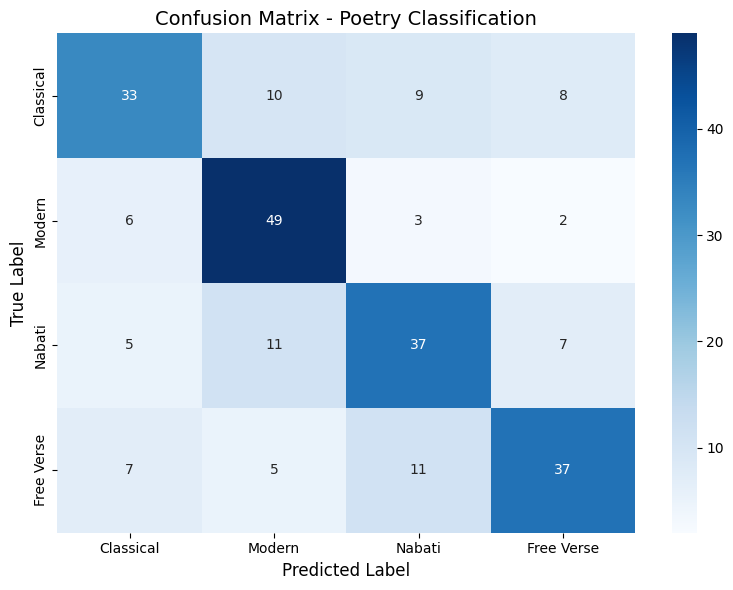

Overall Accuracy: 65.00%


In [26]:
# ====================================================
# SIMPLE CONFUSION MATRIX
# ====================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# After training, get predictions
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Define your class names
class_names = ['Classical', 'Modern', 'Nabati', 'Free Verse']  # Replace with your actual classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Poetry Classification', fontsize=14)
plt.tight_layout()
plt.show()

# Print accuracy
accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"Overall Accuracy: {accuracy:.2%}")